Polynomial vs Linear Regression


In [64]:
import pandas as pd
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [65]:
import numpy as np
import matplotlib.pyplot as plt








In [66]:
# Reproducibility
np.random.seed(42)


In [67]:
# Generate x values between -3 and 3
x = np.random.uniform(-3, 3, size=200)

# Generate y as a quadratic function of x + noise
y = 0.5 * x**2 + x + 2 + np.random.normal(0, 1, size=200)

In [68]:
# Sort x for cleaner line plotting later
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

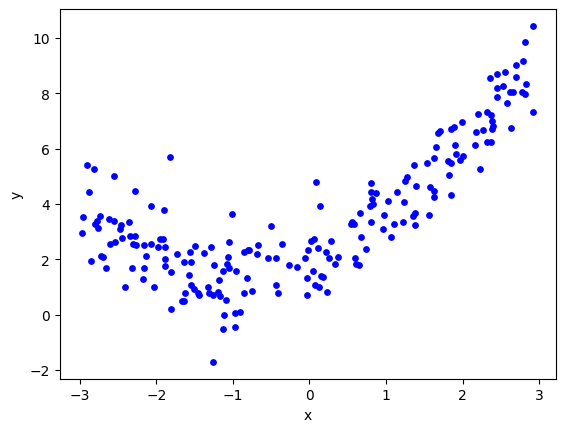

In [69]:

# Scatter plot of the data
plt.scatter(x, y, color='blue', s=15)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [75]:
X = x.reshape(-1, 1)

# --- Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_lin_pred = lin_reg.predict(x_sorted.reshape(-1, 1))

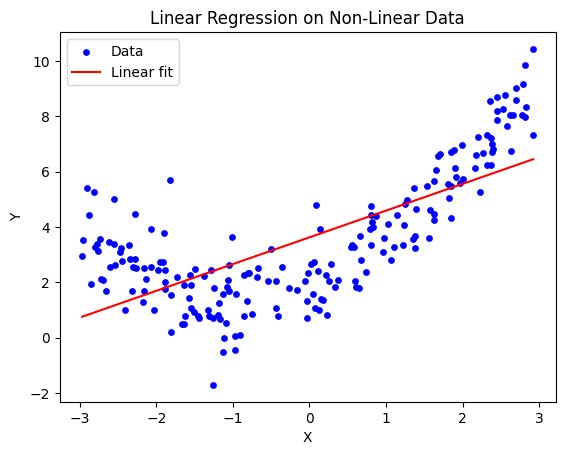

In [76]:
import matplotlib.pyplot as plt

plt.scatter(x, y, color='blue', s=15, label='Data')
plt.plot(x_sorted, y_lin_pred, color='red', label='Linear fit')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression on Non-Linear Data")
plt.legend()

plt.show()

In [77]:
r2_score(y, lin_reg.predict(X))

0.5079986302352673

In [78]:
poly=  PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(X)

In [91]:
poly_reg = LinearRegression()
poly_reg.fit(x_poly, y)

# Prediction ke liye SORTED x use karo, x_poly nahi
x_sorted_poly = poly.transform(x_sorted.reshape(-1, 1))
y_poly_pred = poly_reg.predict(x_sorted_poly)

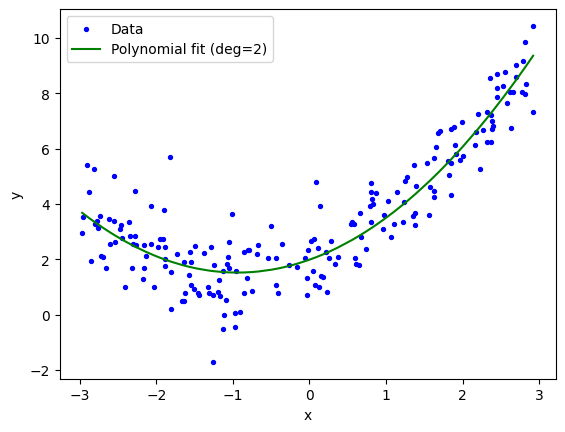

In [92]:
plt.scatter(x, y, color='blue', s=8, label='Data')
plt.plot(x_sorted, y_poly_pred, color='green', label='Polynomial fit (deg=2)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [93]:
r2_score(y, poly_reg.predict(x_poly))

0.8377827271688484

In [99]:
# if degree is 15
poly=  PolynomialFeatures(degree=20)
x_poly=poly.fit_transform(X)

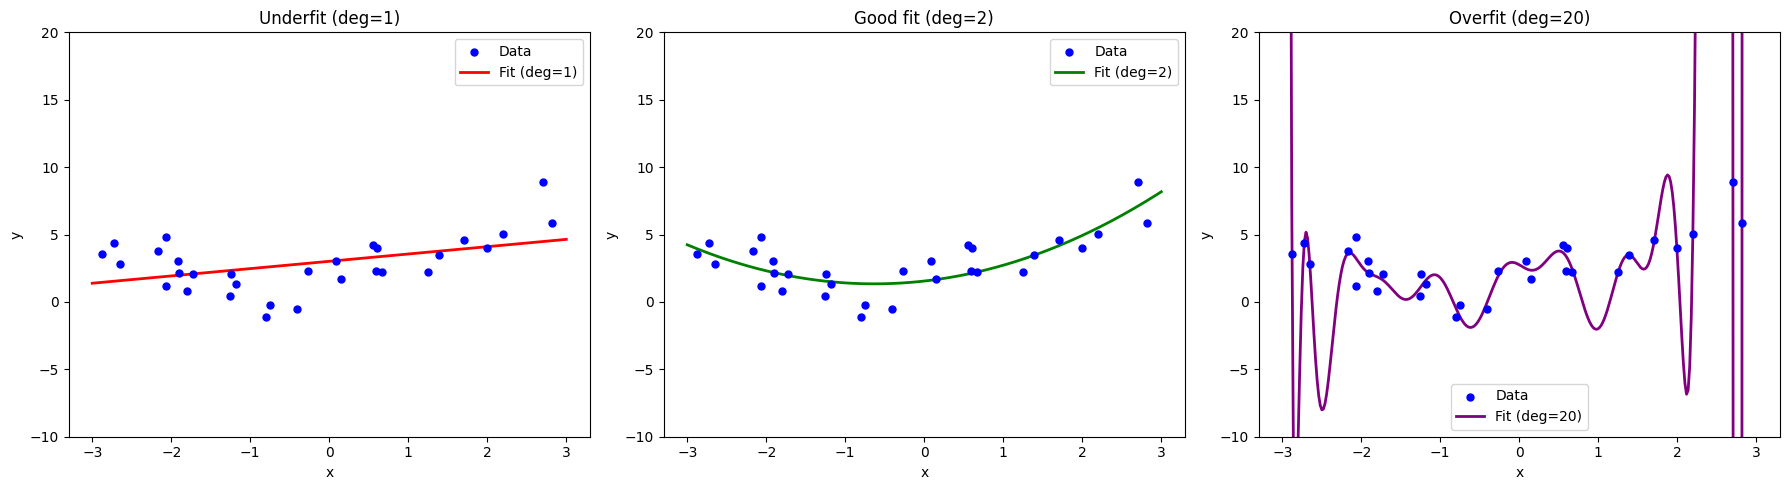

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)

x = np.random.uniform(-3, 3, size=30)
y = 0.5 * x**2 + x + 2 + np.random.normal(0, 1.5, size=30)

X = x.reshape(-1, 1)
x_smooth = np.linspace(-3, 3, 300).reshape(-1, 1)   # smooth line ke liye

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_lin_pred = lin_reg.predict(x_smooth)

axes[0].scatter(x, y, color='blue', s=25, label='Data', zorder=5)
axes[0].plot(x_smooth, y_lin_pred, color='red', linewidth=2, label='Linear fit')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(); axes[0].set_ylim(-10, 20)

# --- 2. Polynomial - Good degree (2) ---
poly_good = PolynomialFeatures(degree=2)
X_poly_good = poly_good.fit_transform(X)
poly_reg_good = LinearRegression()
poly_reg_good.fit(X_poly_good, y)
y_poly_good_pred = poly_reg_good.predict(poly_good.transform(x_smooth))

axes[1].scatter(x, y, color='blue', s=25, label='Data', zorder=5)
axes[1].plot(x_smooth, y_poly_good_pred, color='green', linewidth=2, label='Polynomial fit (deg=2)')
axes[1].set_title('Polynomial Regression - Good Degree')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].legend(); axes[1].set_ylim(-10, 20)

# --- 3. Polynomial - Bad degree (20) - Overfit ---
poly_bad = PolynomialFeatures(degree=20)
X_poly_bad = poly_bad.fit_transform(X)
poly_reg_bad = LinearRegression()
poly_reg_bad.fit(X_poly_bad, y)
y_poly_bad_pred = poly_reg_bad.predict(poly_bad.transform(x_smooth))

axes[2].scatter(x, y, color='blue', s=25, label='Data', zorder=5)
axes[2].plot(x_smooth, y_poly_bad_pred, color='purple', linewidth=2, label='Polynomial fit (deg=20)')
axes[2].set_title('Polynomial Regression - Bad Degree (Overfit)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
axes[2].legend(); axes[2].set_ylim(-10, 20)

plt.tight_layout()
plt.show()